In [1]:
# ==========================================
# 1. IMPORTS AND SETUP
# ==========================================
!pip install lightgbm


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, average_precision_score
from collections import Counter
import lightgbm as lgb
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')
# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
def load_data(sample_size=None):
    """
    Load the IEEE fraud detection dataset with debug messages.
    
    Args:
        sample_size (int or None): Number of rows to read from each CSV.
                                   If None, load the full dataset.
    """
    # Check what files exist
    print("📂 Files in current directory:", os.listdir())
    
    try:
        print("📥 Loading train_transaction.csv ...")
        train_transaction = pd.read_csv('train_transaction.csv', nrows=sample_size)
        
        print("📥 Loading train_identity.csv ...")
        train_identity = pd.read_csv('train_identity.csv', nrows=sample_size)
        
        print("📥 Loading test_transaction.csv ...")
        test_transaction = pd.read_csv('test_transaction.csv', nrows=sample_size)
        
        print("📥 Loading test_identity.csv ...")
        test_identity = pd.read_csv('test_identity.csv', nrows=sample_size)
        
        print("📥 Loading sample_submission.csv ...")
        sample_submission = pd.read_csv('sample_submission.csv')
        
        print(f"✅ Training transaction data shape: {train_transaction.shape}")
        print(f"✅ Training identity data shape: {train_identity.shape}")
        print(f"✅ Test transaction data shape: {test_transaction.shape}")
        print(train_transaction.head())
        print(train_transaction.columns)

        print(f"✅ Test identity data shape: {test_identity.shape}")
        
        return train_transaction, train_identity, test_transaction, test_identity, sample_submission
    
    except FileNotFoundError as e:
        print(f"❌ File not found: {e.filename}")
        return None, None, None, None, None


# ========================
# USAGE
# ========================
train_transaction, train_identity, test_transaction, test_identity, sample_submission = load_data(sample_size=50000)

📂 Files in current directory: ['.ipynb_checkpoints', 'fraud_detection.ipynb', 'sample_submission.csv', 'test_identity.csv', 'test_transaction.csv', 'train_identity.csv', 'train_transaction.csv']
📥 Loading train_transaction.csv ...
📥 Loading train_identity.csv ...
📥 Loading test_transaction.csv ...
📥 Loading test_identity.csv ...
📥 Loading sample_submission.csv ...
✅ Training transaction data shape: (50000, 394)
✅ Training identity data shape: (50000, 41)
✅ Test transaction data shape: (50000, 393)
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5

=== TRANSACTION DATA EXPLORATION ===
Shape: (50000, 394)
Memory usage: 173.3 MB
Missing values per column:
D7       47644
dist2    46645
D13      46322
D12      45903
D14      45672
D6       45175
D9       41250
D8       41250
M7       40776
M8       40776
dtype: int64

=== TARGET VARIABLE DISTRIBUTION ===
Non-fraud: 48,643 (97.29%)
Fraud: 1,357 (2.71%)


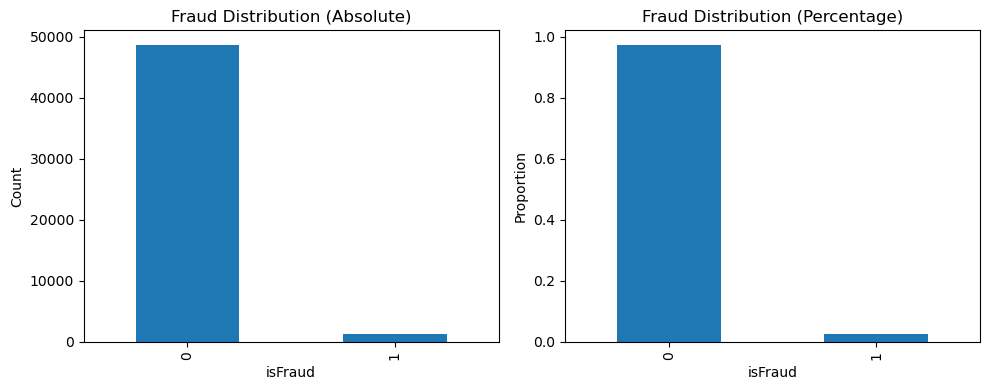


=== IDENTITY DATA EXPLORATION ===
Shape: (50000, 41)
Overlap with transaction data: 16456


In [3]:
# ==========================================
# 3. DATA EXPLORATION
# ==========================================

def explore_data(train_transaction, train_identity):
    """Explore the training data"""
    
    print("=== TRANSACTION DATA EXPLORATION ===")
    print(f"Shape: {train_transaction.shape}")
    print(f"Memory usage: {train_transaction.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    print(f"Missing values per column:")
    print(train_transaction.isnull().sum().sort_values(ascending=False).head(10))
    
    print("\n=== TARGET VARIABLE DISTRIBUTION ===")
    fraud_counts = train_transaction['isFraud'].value_counts()
    fraud_rate = train_transaction['isFraud'].mean()
    print(f"Non-fraud: {fraud_counts[0]:,} ({100*(1-fraud_rate):.2f}%)")
    print(f"Fraud: {fraud_counts[1]:,} ({100*fraud_rate:.2f}%)")
    
    # Plot target distribution
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    train_transaction['isFraud'].value_counts().plot(kind='bar')
    plt.title('Fraud Distribution (Absolute)')
    plt.xlabel('isFraud')
    plt.ylabel('Count')
    
    plt.subplot(1, 2, 2)
    train_transaction['isFraud'].value_counts(normalize=True).plot(kind='bar')
    plt.title('Fraud Distribution (Percentage)')
    plt.xlabel('isFraud')
    plt.ylabel('Proportion')
    
    plt.tight_layout()
    plt.show()
    
    print("\n=== IDENTITY DATA EXPLORATION ===")
    if train_identity is not None:
        print(f"Shape: {train_identity.shape}")
        print(f"Overlap with transaction data: {len(set(train_identity['TransactionID']) & set(train_transaction['TransactionID']))}")

# Explore the data
if train_transaction is not None:
    explore_data(train_transaction, train_identity)

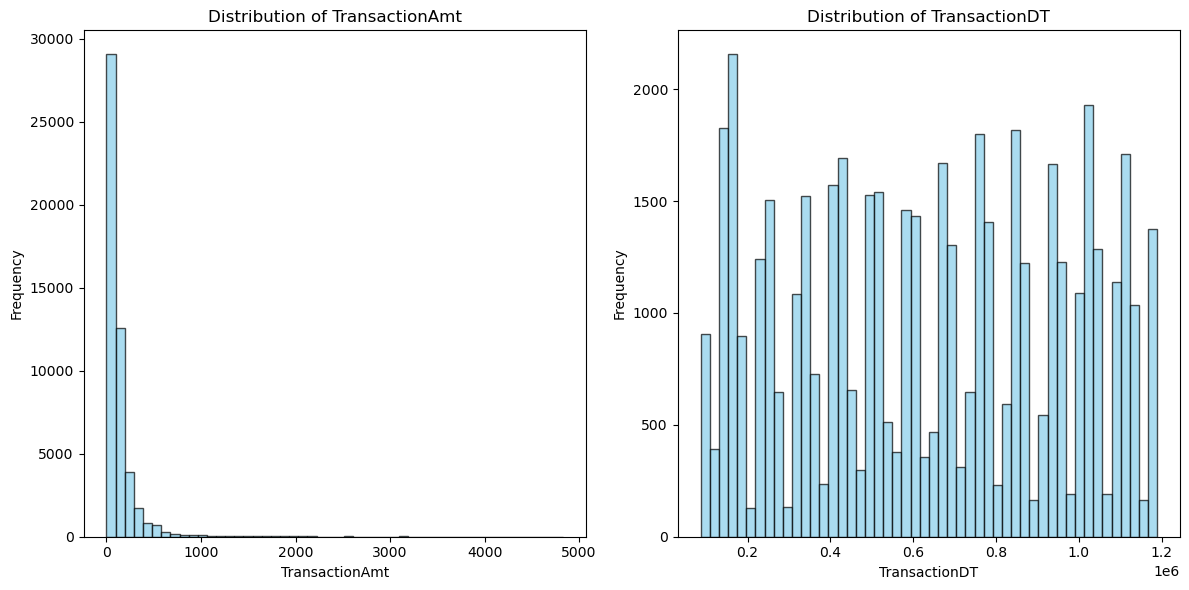

In [4]:
# ==========================================
# 3. EDA (Exploratory Data Analysis)
# ==========================================
def plot_continuous_distributions(df):
    """Plot histograms for continuous variables"""
    continuous_columns = ['TransactionAmt', 'TransactionDT']  # Add more columns as needed
    
    plt.figure(figsize=(12, 6))
    for i, column in enumerate(continuous_columns, 1):
        plt.subplot(1, len(continuous_columns), i)
        df[column].plot(kind='hist', bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


# Run the EDA functions
if train_transaction is not None:
    plot_continuous_distributions(train_transaction)
    # plot_correlation_matrix(train_transaction)
    # plot_missing_values(train_transaction)
    # plot_outliers(train_transaction)

Missing values found in numeric columns. Cleaning data...


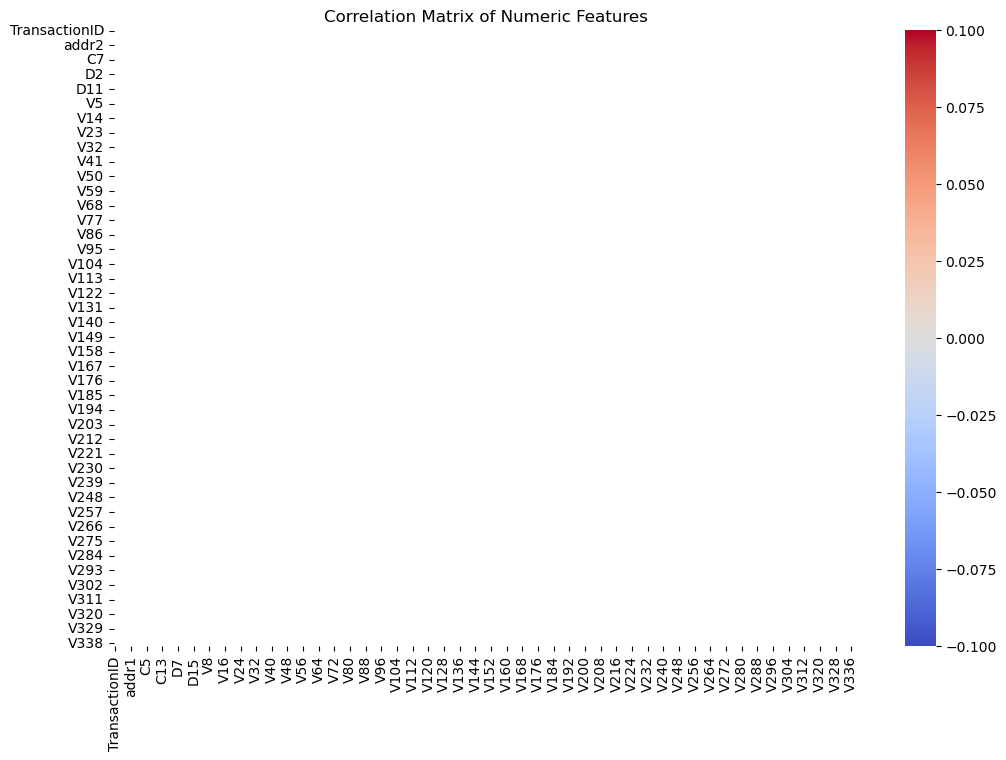

In [5]:
def plot_correlation_matrix(df):
    """Plot correlation matrix for numeric variables"""
    
    # Select numeric columns
    numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    if len(numeric_columns) == 0:
        print("No numeric columns found.")
        return
    
    # Check for missing values in numeric columns
    if df[numeric_columns].isnull().sum().any():
        print("Missing values found in numeric columns. Cleaning data...")
        df = df.dropna(subset=numeric_columns)  # Or use fillna() to handle missing values
    
    # Compute correlation matrix
    correlation_matrix = df[numeric_columns].corr()
    
    # Plot correlation matrix
    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Matrix of Numeric Features')
    plt.show()

# Run the EDA function
if train_transaction is not None:
    plot_correlation_matrix(train_transaction)

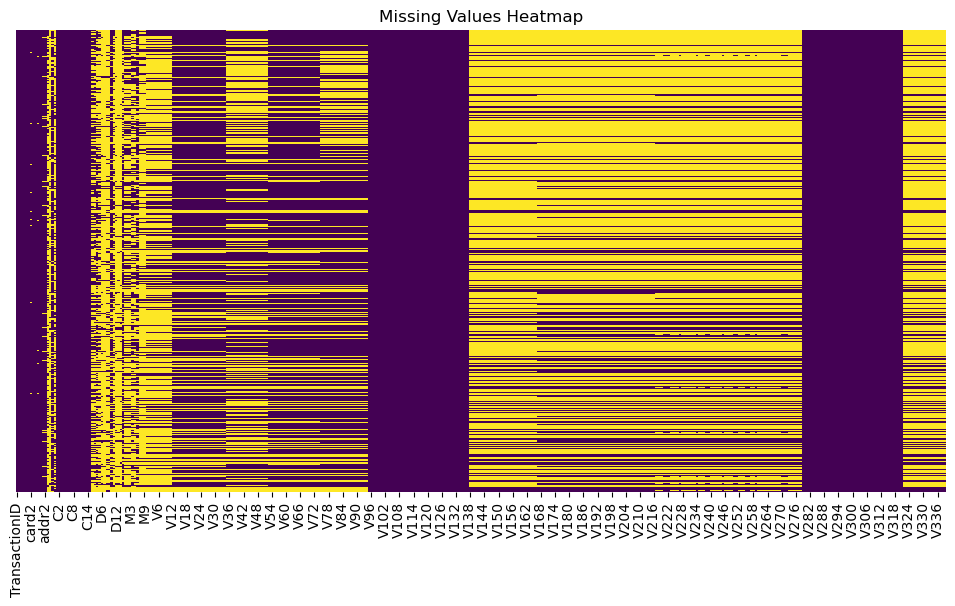

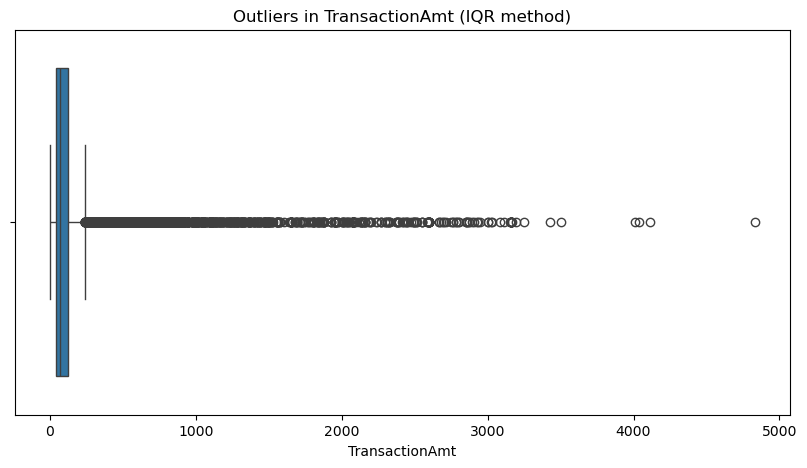

Outliers in TransactionAmt: 5503


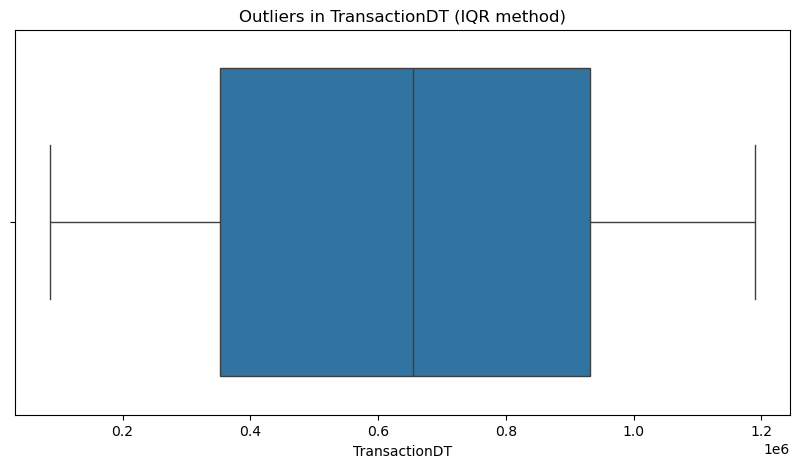

Outliers in TransactionDT: 0


In [6]:
def plot_missing_values(df):
    """Plot missing values heatmap"""
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
    plt.title('Missing Values Heatmap')
    plt.show()

def plot_outliers(df):
    """Detect and plot outliers using IQR method"""
    continuous_columns = ['TransactionAmt', 'TransactionDT']  # Add more columns as needed
    
    for column in continuous_columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=df[column])
        plt.title(f'Outliers in {column} (IQR method)')
        plt.show()
        
        print(f"Outliers in {column}: {len(outliers)}")

# Run the EDA functions
if train_transaction is not None:
    
     plot_missing_values(train_transaction)
     plot_outliers(train_transaction)

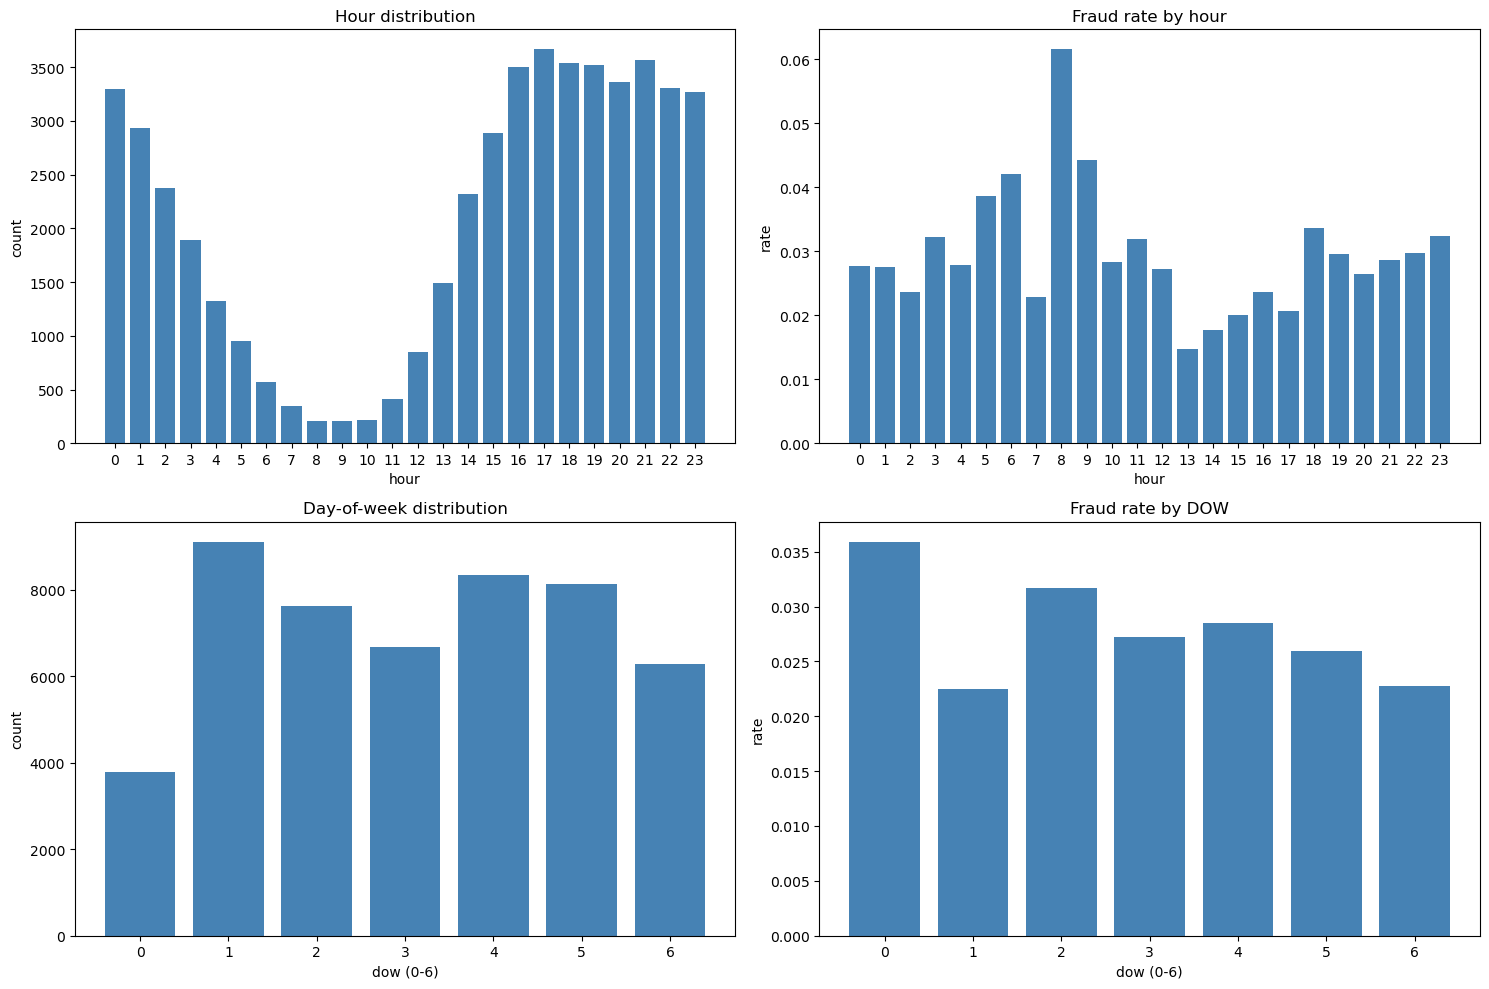

In [7]:


# Fill missing 'TransactionDT' and 'isFraud' values with default values or drop rows
train_transaction['TransactionDT'] = pd.to_numeric(train_transaction['TransactionDT'], errors='coerce')
train_transaction['isFraud'] = train_transaction['isFraud'].fillna(0)  # Assuming missing fraud data as non-fraud (0)
# Drop rows where 'TransactionDT' or 'isFraud' are NaN (if needed)
train_transaction = train_transaction.dropna(subset=['TransactionDT', 'isFraud'])

# Convert TransactionDT (seconds) to datetime features
# Assuming TransactionDT is seconds from a reference point
train_transaction['TransactionDT_hours'] = (train_transaction['TransactionDT'] / 3600) % 24
train_transaction['TransactionDT_hours'] = train_transaction['TransactionDT_hours'].astype(int)

# Calculate day of week (assuming each day is 86400 seconds)
train_transaction['TransactionDT_dow'] = ((train_transaction['TransactionDT'] / 86400) % 7).astype(int)

# Create the 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Hour distribution (top left)
hour_counts = train_transaction['TransactionDT_hours'].value_counts().sort_index()
axes[0, 0].bar(hour_counts.index, hour_counts.values, color='steelblue')
axes[0, 0].set_xlabel('hour')
axes[0, 0].set_ylabel('count')
axes[0, 0].set_title('Hour distribution')
axes[0, 0].set_xticks(range(24))

# 2. Fraud rate by hour (top right)
fraud_by_hour = train_transaction.groupby('TransactionDT_hours')['isFraud'].mean()
axes[0, 1].bar(fraud_by_hour.index, fraud_by_hour.values, color='steelblue')
axes[0, 1].set_xlabel('hour')
axes[0, 1].set_ylabel('rate')
axes[0, 1].set_title('Fraud rate by hour')
axes[0, 1].set_xticks(range(24))

# 3. Day-of-week distribution (bottom left)
dow_counts = train_transaction['TransactionDT_dow'].value_counts().sort_index()
axes[1, 0].bar(dow_counts.index, dow_counts.values, color='steelblue')
axes[1, 0].set_xlabel('dow (0-6)')
axes[1, 0].set_ylabel('count')
axes[1, 0].set_title('Day-of-week distribution')
axes[1, 0].set_xticks(range(7))

# 4. Fraud rate by DOW (bottom right)
fraud_by_dow = train_transaction.groupby('TransactionDT_dow')['isFraud'].mean()
axes[1, 1].bar(fraud_by_dow.index, fraud_by_dow.values, color='steelblue')
axes[1, 1].set_xlabel('dow (0-6)')
axes[1, 1].set_ylabel('rate')
axes[1, 1].set_title('Fraud rate by DOW')
axes[1, 1].set_xticks(range(7))

plt.tight_layout()
plt.show()